In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *

# This library
from compressibleSPH import *
from compressibleSPH.modules.timestep.compressible import computeTimestep

# The case utilities that contain all the case setup functions for the various test cases
from compressibleSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:

R = 1
L = 2 *3 * R
nx = 192
dx = L / nx
targetDt = 0.0005
rho0 = 1
freeSurface = True
band = 0
fps = 50
timeLimit = 1

dim = 2
n_h = 4


extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'rho0': rho0,

    'R': R,
    
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()



dx = L / (nx)
band = 0

domain = buildDomainDescription(L + dx * (band) * 2, dim, True, device, dtype)
interiorDomain = buildDomainDescription(L, dim, False, device, dtype)

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.symplecticEuler,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx + band * 2
config.dx = (interiorDomain.max[0] - interiorDomain.min[0]) / (nx)

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()


schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False

schemeConfig.surfaceDetectionConfig.active = True
schemeConfig.fluid.fixedSoundSpeed = 50.0

schemeConfig.pressureForceTerm = PressureForceScheme.Antuono

In [4]:
schemeConfig.gravityConfig.active = False
# schemeConfig.gravityConfig.type = GravityType.PotentialField
# schemeConfig.gravityConfig.magnitude = B

# schemeConfig.gravityConfig.origin =[0.0, 0.0]

No fluid particles found. Returning original state.


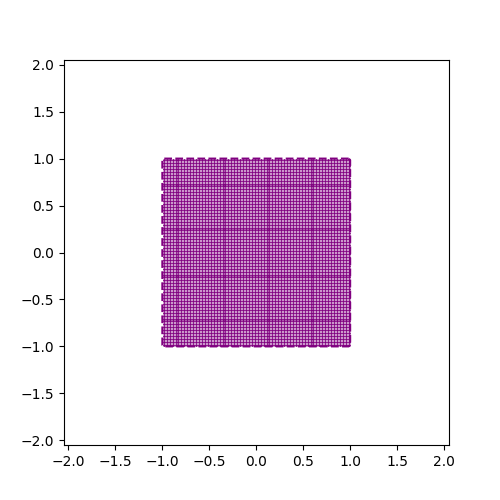

In [5]:

H = 1

fluid_a = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('box')['function'](x, torch.tensor([H,H]).to(points.device)), torch.tensor([0,0]).to(points.device)), invert = False)



# fluid_a = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('circle')['function'](x, torch.tensor(R).to(points.device)), torch.tensor([0,0.]).to(points.device)), invert = False)
# fluid_b = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('circle')['function'](x, torch.tensor(1/2).to(points.device)), torch.tensor([0.75,0.]).to(points.device)), invert = False)


regions = []

regions.append(buildRegion(config, schemeConfig, fluid_a, RegionType.Fluid, initialConditions = {}))

for region in regions:
    region = filterRegion(region, regions)


for region in regions:
    region = filterRegion(region, regions)

    


fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
    
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

import matplotlib.patches as patches

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

for ax in axis.flatten():
    ax.set_xlim(-2.05*R, 2.05*R)
    ax.set_ylim(-2.05*R, 2.05*R)


compressibleSystem = initializeWeaklyCompressibleSimulation(regions, config, schemeConfig, SimulationSystem, SimulationState, verbose = True)

In [6]:

omega = 4

compressibleSystem.state.velocities[:,0] = omega * compressibleSystem.state.positions[:,1]
compressibleSystem.state.velocities[:,1] = -omega * compressibleSystem.state.positions[:,0]

In [7]:
nu_inviscid = alphaToNu(schemeConfig.diffusionParams.inviscidAlpha, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
alpha_effective = nuToAlpha(schemeConfig.diffusionParams.viscidNu, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
print(f"nu_inviscid: {nu_inviscid}, alpha_effective: {alpha_effective}")

nu_inviscid: 0.0078125, alpha_effective: 0.00128


In [8]:
# compressibleSystem.state.positions = shuffleParticles(compressibleSystem.state, config, schemeConfig, 128, jitterAmount = 0.5)

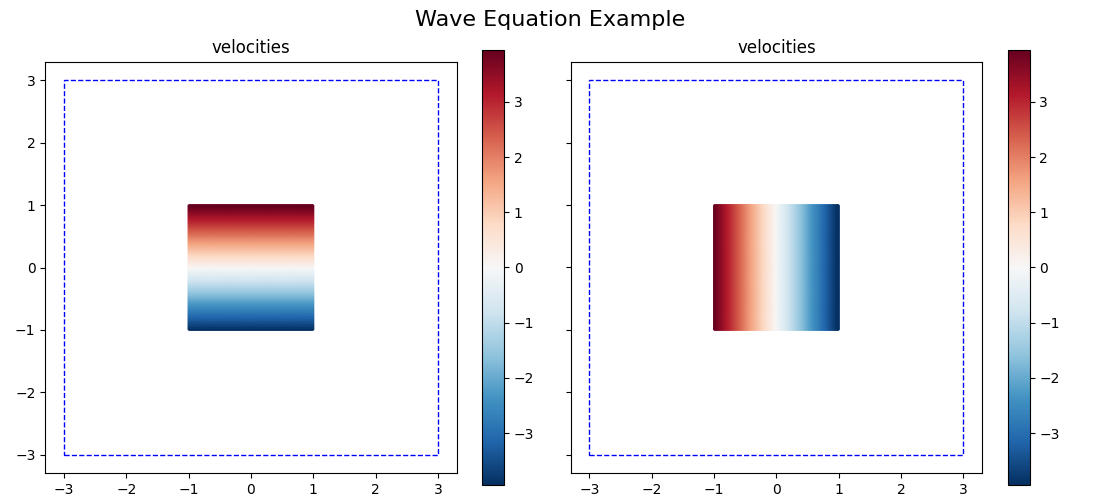

In [9]:
runningState = compressibleSystem.initializeNewState()

from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap,VisualizeOptions
markerSize = 4
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.velocities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.x,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            #     streamLines = True
            # ),
            # boundaryVisualization = VisualizeOptions.Visualize,
            # # vMin=1e-10,
            # stream
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "velocities",
            mapping = Mapping.y,
            # plottingOperation = OperationProperties(
            #     operation = WarpOperation.Curl,
            #     kernel = config.kernel,
            #     supportMode = SupportScheme.Gather, # cullen switch E.1 in the CRK paper uses gather for density estimation
            # ),
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='matplotlib',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)


# imagePath = f'{exportPath}/images'
# os.makedirs(imagePath, exist_ok = True)
# plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)

In [10]:
runningState = compressibleSystem.initializeNewState()
from compressibleSPH.modules.timestep.weaklyCompressible import computeTimestep

config.dt = computeTimestep(
    system = compressibleSystem,
    config = config,
    compParams = schemeConfig,
    dt = 1e-4,
    systemUpdate = None,
)
print(config.dt)

tensor(0.0002, device='cuda:0')


In [11]:
caseName = 'squarePatch'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'frame_num': 0,
}, **extraData))

In [12]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap, CyclicColorMap
markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            boundaryVisualization = VisualizeOptions.Visualize,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.flare,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            boundaryVisualization = VisualizeOptions.Hide,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)


RFBOutputContext()

In [13]:
runningState = compressibleSystem.initializeNewState()
ke = torch.sum(0.5 * runningState.state.densities * torch.sum(runningState.state.velocities**2, dim=1)) / torch.sum(runningState.state.densities)

schemeConfig.diffusionParams.inviscid = True
schemeConfig.diffusionParams.nu = 0.01
# schemeConfig.shiftProperties.active = False
schemeConfig.fluid.eosType = EquationOfState.isoThermal

schemeConfig.shiftProperties.projectionScheme = ShiftingProjectionScheme.mat
schemeConfig.surfaceDetectionConfig.scheme = SurfaceDetectionScheme.Barecasco
schemeConfig.surfaceDetectionConfig.normalSource = NormalSource.LambdaGrad
schemeConfig.shiftProperties.computeMach = True

schemeConfig.shiftProperties.active = True
schemeConfig.fluid.fixedSoundSpeed = 34.5
schemeConfig.surfaceDetectionConfig.barecascoThreshold = np.pi/3


schemeConfig.pressureForceTerm = PressureForceScheme.Antuono


config.dt = computeTimestep(
    system = compressibleSystem,
    config = config,
    compParams = schemeConfig,
    dt = 1e-4,
    systemUpdate = None,
)
config.dt = 0.0005
print(config.dt)

0.0005


In [43]:
nSteps = int(timeLimit / config.dt)

runningState = compressibleSystem.initializeNewState()
# nSteps = 400
kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state

    if (i % 10 == 0 and i > 0) or (i == nSteps - 1):
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{timeLimit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/2000 [00:00<?, ?it/s]

In [15]:
runningState.state.densities.min(), runningState.state.densities.mean(), runningState.state.densities.max()

(tensor(0.9859, device='cuda:0'),
 tensor(0.9943, device='cuda:0'),
 tensor(1.0021, device='cuda:0'))

In [16]:
from sphWarpCore import SupportScheme as SupportSchemeWarp
adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.0, supportMode = SupportSchemeWarp.SuperSymmetric,
        priorNeighborhood = None,
        verbose = False)

    
fs, fsm, n = detectFreeSurface(runningState.state, config, schemeConfig, schemeConfig.surfaceDetectionConfig, adjacency, returnNormals = True)

C, Evals, renormalizationState_ = computeRenormalizationMatrices(
    queryParticles = runningState.state,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        operationMode = OperationDirection.AllToAll,
        supportMode = SupportSchemeWarp.SuperSymmetric
    ),
    domain = config.domain,
    adjacency = adjacency,
    returnEigVals = True
)
lMin = torch.min(torch.abs(Evals), dim = -1).values

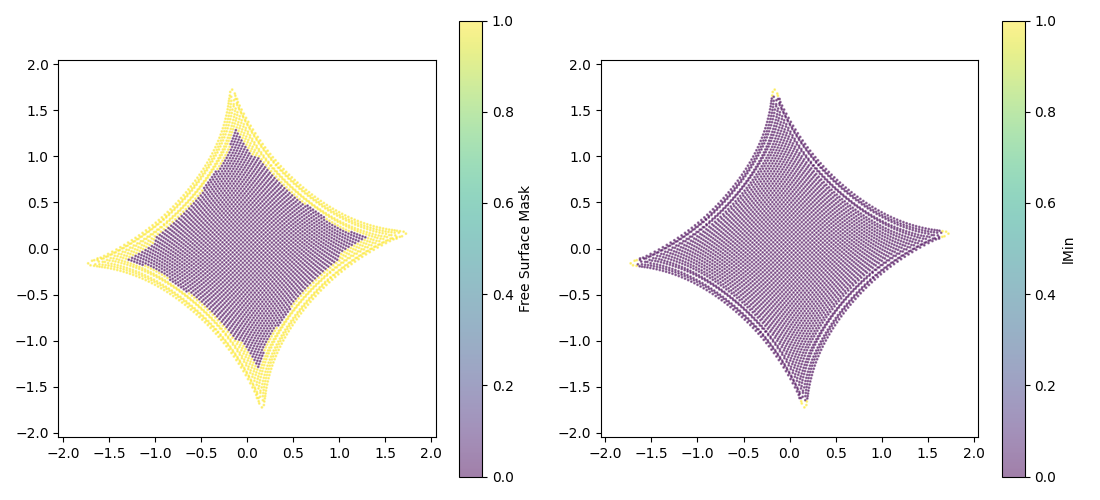

In [17]:


fig, axis = plt.subplots(1, 2, figsize=(11, 5), squeeze=False)
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())
for ax in axis.flatten():
    ax.set_xlim(-2.05*R, 2.05*R)
    ax.set_ylim(-2.05*R, 2.05*R)
    
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = fsm.cpu().numpy() > 0.5, alpha = 0.5)

fig.colorbar(sc, ax = axis[0,0], label = 'Free Surface Mask')

sc = axis[0,1].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = lMin.cpu().numpy() < 0.4, alpha = 0.5)
fig.colorbar(sc, ax = axis[0,1], label = 'lMin')


fig.tight_layout()

In [18]:
display(schemeConfig.surfaceDetectionConfig)
display(schemeConfig.shiftProperties)
display(schemeConfig)

SurfaceDetectionConfig(active=True, colorFieldThreshold=0.75, colorFieldGradThreshold=10.0, barecascoThreshold=1.0471975511965976, expansionIterations=1, scheme=<SurfaceDetectionScheme.Barecasco: 2>, normalSource=<NormalSource.LambdaGrad: 2>)

ShiftProperties(iterations=1, CFL=0.3, computeMach=True, maxC=0.3, active=True, scheme=<ShiftingScheme.deltaSPH: 1>, projectionScheme=<ShiftingProjectionScheme.mat: 2>, summationDensity=False, surfaceScaling=0.1, threshold=0.5, projectQuantities=False)

WeaklyCompressibleSPHConfig(fluid=fluidProperties(eosType=<EquationOfState.isoThermal: 'isoThermal'>, restDensity=1.0, polytropicExponent=7.0, kappa=1.3, gas_constant=8.314, molarMass=0.02897, fixedSoundSpeed=34.5), adaptiveSupportScheme=<AdaptiveSupportScheme.Owen: 2>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=False, diffusionParams=WeaklyCompressibleDiffusionParams(inviscid=True, inviscidAlpha=0.01, viscidNu=0.001, densityDelta=0.1, densityDiffusionTerm=<DensityDiffusionScheme.deltaSPH: 0>), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.NoneSwitch: 6>, limitXi=True, correctVelocityGradient=False, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='Compressible SPH', boundaryConditions=[], dt_viscosityConstraint=True, dt_accelerationConstraint=True, dt_acousticConstraint=True, pressureForceTerm=<PressureForceScheme.Antuono: 2>, shiftProperties=ShiftProperties(ite

In [19]:

# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'frame_num': i,
# }))

In [20]:
# ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 120 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# # ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# # subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# # ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# # subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# # now copy the output.mp4 and out.gif to the parent directory for easier access
# shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# # shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

In [21]:
adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.0, supportMode = SupportSchemeWarp.SuperSymmetric,
        priorNeighborhood = None,
        verbose = False)

fs, fsm, n = detectFreeSurface(runningState.state, config, schemeConfig, schemeConfig.surfaceDetectionConfig, adjacency, returnNormals = True)

C, Evals, renormalizationState_ = computeRenormalizationMatrices(
    queryParticles = runningState.state,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        operationMode = OperationDirection.AllToAll,
        supportMode = SupportSchemeWarp.SuperSymmetric
    ),
    domain = config.domain,
    adjacency = adjacency,
    returnEigVals = True
)
lMin = torch.min(torch.abs(Evals), dim = -1).values

In [22]:
from diffSPH.simple import *
from diffSPH.schemes.weaklyCompressible import WeaklyCompressibleState as diffSPHState

In [23]:
particles = diffSPHState(
    positions = runningState.state.positions.clone(),
    supports = runningState.state.supports.clone(),
    masses = runningState.state.masses.clone(),
    densities = runningState.state.densities.clone(),
    velocities = runningState.state.velocities.clone(),

    kinds = runningState.state.kinds.clone(),
    materials = runningState.state.materials.clone(),
    UIDs = runningState.state.UIDs.clone(),
    UIDcounter = runningState.state.UIDcounter,

    pressures = None,
    soundspeeds = torch.ones_like(runningState.state.positions[:,0]) * schemeConfig.fluid.fixedSoundSpeed,
)
wrappedKernel = KernelType.Wendland4

In [24]:
diffSPHconfig = {
    'neighborhood': {
        'verletScale': 1.0,
        'computeHessian': True,
        'computeDkDh': True,
        'only_j': False,
    },
}


neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = diffSPHconfig['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None, computeHessian=diffSPHconfig['neighborhood']['computeHessian'], computeDkDh=diffSPHconfig['neighborhood']['computeDkDh'], only_j = diffSPHconfig['neighborhood']['only_j'])

particles.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries


In [25]:
from diffSPH.modules.renorm import computeCovarianceMatrices
from diffSPH.modules.density import computeGradRhoL as computeGradRhoLdiffSPH
from diffSPH.modules.density import computeGradRho as computeGradRhodiffSPH
from diffSPH.modules.densityDiffusion import computeDensityDeltaTerm as computeDensityDeltaTermdiffSPH

from diffSPH.modules.pressureForce import computePressureForce as computePressureForcediffSPH
from diffSPH.modules.momentum import computeMomentum as computeMomentumpdiffSPH

In [26]:
particles.covarianceMatrices, particles.gradCorrectionMatrices, particles.eigenValues = computeCovarianceMatrices(particles, wrappedKernel, neighbors.get('normal'), SupportScheme.Scatter, config)


In [27]:
diff = (particles.gradCorrectionMatrices - renormalizationState_.renormalizationMatrices)
print(f"Max difference in grad correction matrices: {diff.abs().max()}")

Max difference in grad correction matrices: 1.4632940292358398e-05


In [28]:
diffEVs = (particles.eigenValues - Evals)
print(f"Max difference in eigenvalues: {diffEVs.abs().max()}")
# print(f"Max difference in lMin: {(torch.min(torch.abs(particles.eigenValues), dim = -1).values - lMin).abs().max()}")
print(particles.eigenValues)
print(Evals)

Max difference in eigenvalues: 5.364418029785156e-07
tensor([[0.2904, 0.1064],
        [0.4190, 0.2107],
        [0.6183, 0.3331],
        ...,
        [0.6183, 0.3331],
        [0.4190, 0.2107],
        [0.2904, 0.1064]], device='cuda:0')
tensor([[0.2904, 0.1064],
        [0.4190, 0.2107],
        [0.6183, 0.3331],
        ...,
        [0.6183, 0.3331],
        [0.4190, 0.2107],
        [0.2904, 0.1064]], device='cuda:0')


In [29]:

particles.gradRhoL = computeGradRhoLdiffSPH(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, diffSPHconfig)
particles.gradRho = computeGradRhodiffSPH(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, diffSPHconfig)

particles.gradRhoL

tensor([[-0.0022,  0.0039],
        [ 0.0013,  0.0045],
        [ 0.0014,  0.0007],
        ...,
        [-0.0014, -0.0007],
        [-0.0012, -0.0045],
        [ 0.0022, -0.0039]], device='cuda:0')

In [30]:
gradRhoL = computeGradRhoL(runningState.state, config, schemeConfig, adjacency, L = renormalizationState_.renormalizationMatrices)
gradRho = computeGradRho(runningState.state, config, schemeConfig, adjacency)

gradRhoL

tensor([[-0.0022,  0.0039],
        [ 0.0013,  0.0045],
        [ 0.0014,  0.0007],
        ...,
        [-0.0014, -0.0007],
        [-0.0012, -0.0045],
        [ 0.0022, -0.0039]], device='cuda:0')

In [31]:
gradRhoL_diff = (particles.gradRhoL -gradRhoL)
print(f"Max difference in gradRhoL: {gradRhoL_diff.abs().max()}")

Max difference in gradRhoL: 2.505257725715637e-07


In [32]:
diffSPHconfig['diffusion'] = {
    'scheme': 'deltaSPH'
}

In [33]:
drhodt_diss = computeDensityDeltaTermdiffSPH(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, diffSPHconfig)
drhodt_diss

tensor([-0.0088,  0.0170,  0.0108,  ...,  0.0108,  0.0169, -0.0088],
       device='cuda:0')

In [34]:
schemeConfig.diffusionParams.densityDiffusionTerm = DensityDiffusionScheme.deltaSPH
drhodt_diss_warp = computeDensityDiffusion(runningState.state, config, schemeConfig, adjacency, gradRho, gradRhoL)
drhodt_diss_warp

tensor([-0.0088,  0.0170,  0.0108,  ...,  0.0108,  0.0169, -0.0088],
       device='cuda:0')

In [35]:
print(f'Max difference in density diffusion term: {(drhodt_diss - drhodt_diss_warp).abs().max()}')

Max difference in density diffusion term: 2.4437904357910156e-06


In [36]:
print(schemeConfig.pressureForceTerm)

PressureForceScheme.Antuono


In [37]:
schemeConfig.surfaceDetectionConfig.barecascoThreshold = np.pi/3


In [38]:
pi = weaklyCompressibleEOS(runningState.state, schemeConfig)
runningState.state.pressures = pi

In [39]:
fs, fsm, n = detectFreeSurface(runningState.state, config, schemeConfig, schemeConfig.surfaceDetectionConfig, adjacency, returnNormals = True) 
runningState.state.surfaceIndicators = (fsm > 0.5).to(torch.int32)
# runningState.state.surfaceIndicators[:] = 0
# runningState.state.surfaceIndicators = None

schemeConfig.pressureForceTerm = PressureForceScheme.Antuono

dvdt = computePressureForceSurfaceAware(runningState.state, config, schemeConfig, adjacency)
dvdt

tensor([[ 0.2887, -0.4367],
        [ 1.1843,  0.8065],
        [ 0.1684,  1.3152],
        ...,
        [-0.1693, -1.3157],
        [-1.1843, -0.8061],
        [-0.2885,  0.4365]], device='cuda:0')

In [40]:
# particles.surfaceMask = (fsm > 0.5).to(torch.int32)
from diffSPH.modules.surfaceDetection import surfaceDetection
diffSPHconfig['targetNeighbors'] = n_h_to_nH(4, dim)
fsd, particles.surfaceMask, particles.surfaceNormals, lMin = surfaceDetection(particles, wrappedKernel, neighbors.get('normal'), SupportScheme.Gather, diffSPHconfig, True)

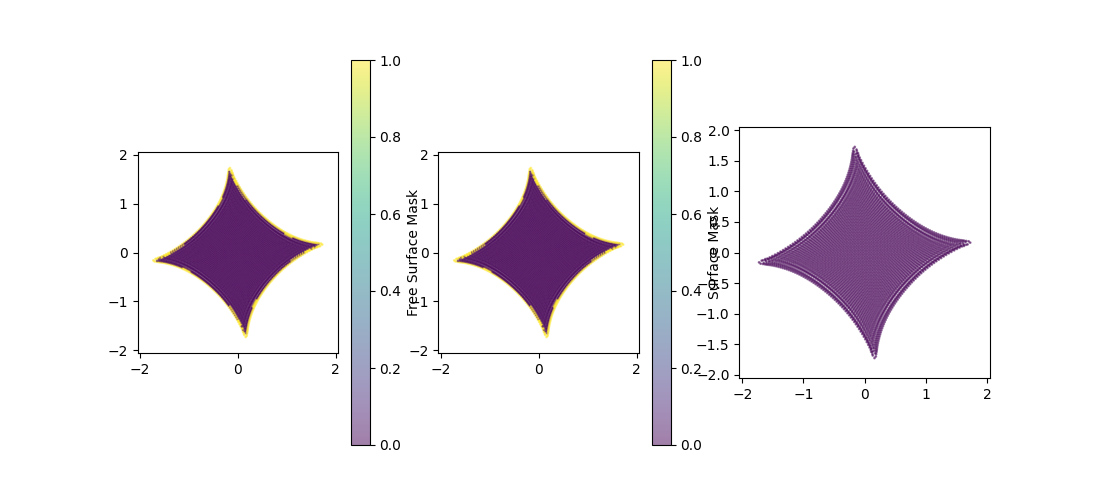

In [41]:
fig, axis = plt.subplots(1, 3, figsize=(11, 5), squeeze=False)
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())
for ax in axis.flatten():
    ax.set_xlim(-2.05*R, 2.05*R)
    ax.set_ylim(-2.05*R, 2.05*R)

sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = fsd.cpu().numpy() > 0.5, alpha = 0.5)
fig.colorbar(sc, ax = axis[0,0], label = 'Free Surface Mask')

sc = axis[0,1].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = fs.cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[0,1], label = 'Surface Mask')

sc = axis[0,2].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = (torch.logical_xor(fsd, fs)).cpu().numpy() < 0.4, alpha = 0.5)


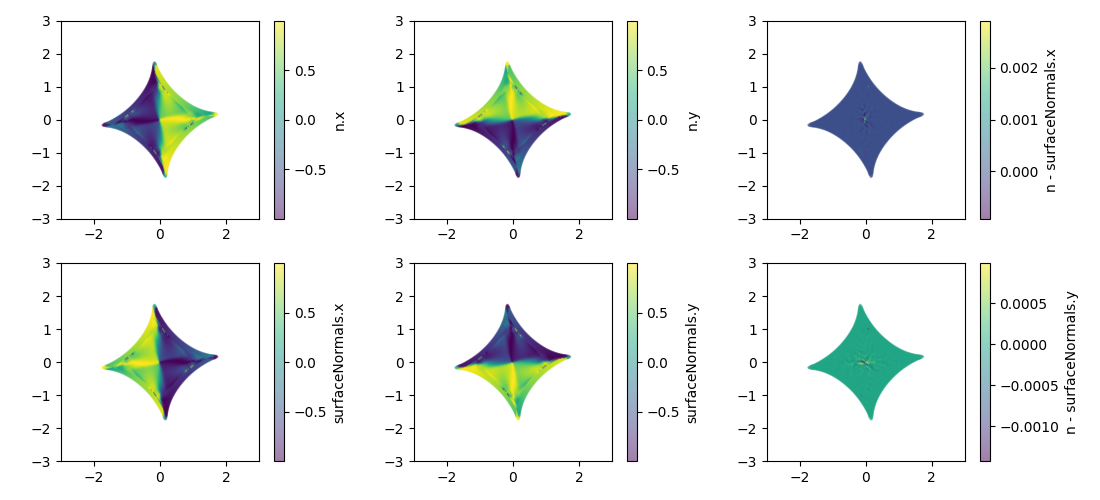

In [42]:
fig, axis = plt.subplots(2, 3, figsize=(11, 5), squeeze=False)

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = n[:,0].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[0,0], label = 'n.x')
sc = axis[0,1].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = n[:,1].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[0,1], label = 'n.y')

sc = axis[1,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = particles.surfaceNormals[:,0].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[1,0], label = 'surfaceNormals.x')
sc = axis[1,1].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = particles.surfaceNormals[:,1].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[1,1], label = 'surfaceNormals.y')

sc = axis[0,2].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = (n + particles.surfaceNormals)[:,0].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[0,2], label = 'n - surfaceNormals.x')
sc = axis[1,2].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = (n + particles.surfaceNormals)[:,1].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[1,2], label = 'n - surfaceNormals.y')

fig.tight_layout()




In [51]:
n

tensor([[-0.9556, -0.2947],
        [-0.9393, -0.3432],
        [-0.9153, -0.4027],
        ...,
        [ 0.9153,  0.4027],
        [ 0.9392,  0.3432],
        [ 0.9556,  0.2947]], device='cuda:0')

In [96]:

print(f'Number of Surface particles: {particles.surfaceMask.sum()} / {len(particles.surfaceMask)}')
particles.pressures = pi
diffSPHconfig['pressure'] = {'term': 'Antuono'}
particles.surfaceMask = (fsm > 0.5).to(torch.int32)
pressureAccel = -computePressureForcediffSPH(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, diffSPHconfig)
pressureAccel

Number of Surface particles: 1548 / 4096


tensor([[-0.1115, -0.1834],
        [ 1.3008,  0.0403],
        [ 0.6639,  0.4204],
        ...,
        [-0.6626, -0.4156],
        [-1.2974, -0.0383],
        [ 0.1131,  0.1842]], device='cuda:0')

In [97]:
maxDiff = (dvdt - pressureAccel).abs().max()
print(f'Max difference in pressure force term: {maxDiff}')
minDiff = (dvdt - pressureAccel).abs().min()
print(f'Min difference in pressure force term: {minDiff}')

Max difference in pressure force term: 6.866455078125e-05
Min difference in pressure force term: 0.0


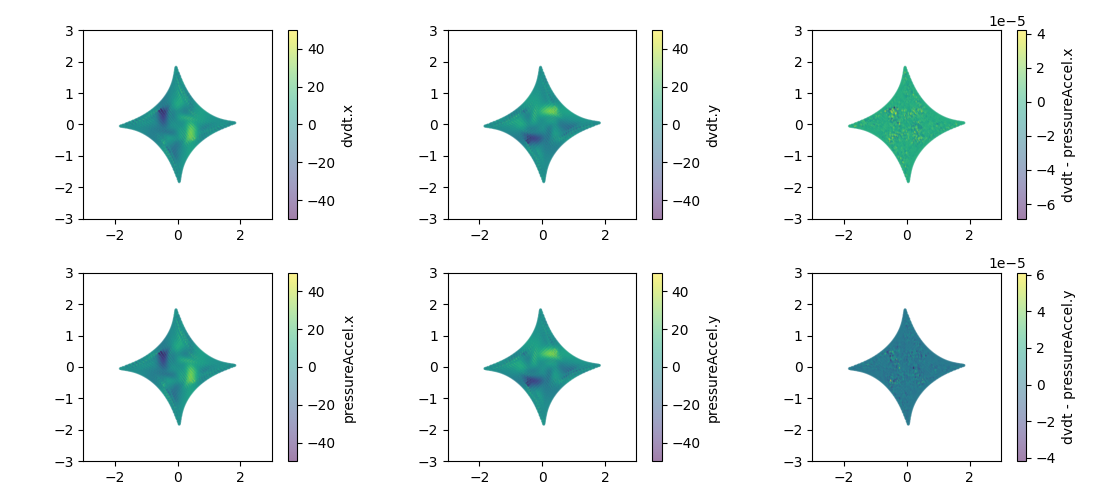

In [98]:
fig, axis = plt.subplots(2, 3, figsize=(11, 5), squeeze=False)

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = dvdt[:,0].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[0,0], label = 'dvdt.x')
sc = axis[0,1].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = dvdt[:,1].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[0,1], label = 'dvdt.y')

sc = axis[1,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = pressureAccel[:,0].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[1,0], label = 'pressureAccel.x')
sc = axis[1,1].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = pressureAccel[:,1].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[1,1], label = 'pressureAccel.y')

sc = axis[0,2].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = (dvdt - pressureAccel)[:,0].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[0,2], label = 'dvdt - pressureAccel.x')
sc = axis[1,2].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = (dvdt - pressureAccel)[:,1].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[1,2], label = 'dvdt - pressureAccel.y')

fig.tight_layout()




In [90]:
drhodt = computeMomentum(runningState.state, config, schemeConfig, adjacency)
drhodt

tensor([-0.0089,  0.0033, -0.0219,  ..., -0.0240,  0.0037, -0.0085],
       device='cuda:0')

In [91]:

drhodtDiffSPH = -computeMomentumpdiffSPH(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, diffSPHconfig)
drhodtDiffSPH

tensor([-0.0089,  0.0033, -0.0219,  ..., -0.0240,  0.0037, -0.0085],
       device='cuda:0')

In [92]:
print(f'Max difference in momentum term: {(drhodt - drhodtDiffSPH).abs().max()}')

Max difference in momentum term: 1.7583370208740234e-06


In [93]:
from diffSPH.modules.velocityDiffusion import computeViscosity_deltaSPH_inviscid
diffSPHconfig['fluid'] = {'rho0': schemeConfig.fluid.restDensity, 'c0': schemeConfig.fluid.fixedSoundSpeed}

dvdt_dissDiff = computeViscosity_deltaSPH_inviscid(particles, wrappedKernel, neighbors.get('fluid'), SupportScheme.Gather, diffSPHconfig)
dvdt_dissDiff

tensor([[-0.0334, -0.2506],
        [ 0.0333,  0.2506],
        [-0.2353,  0.1187],
        ...,
        [ 0.2360, -0.1196],
        [-0.0341, -0.2549],
        [ 0.0341,  0.2549]], device='cuda:0')

In [97]:
dvdt_diss = computeVelocityDiffusion(runningState.state, config, schemeConfig, adjacency)
dvdt_diss

print(dvdt_diss / dvdt_dissDiff)

tensor([[0.4633, 0.4631],
        [0.4630, 0.4631],
        [0.5717, 0.5420],
        ...,
        [0.5728, 0.5425],
        [0.4599, 0.4600],
        [0.4602, 0.4600]], device='cuda:0')


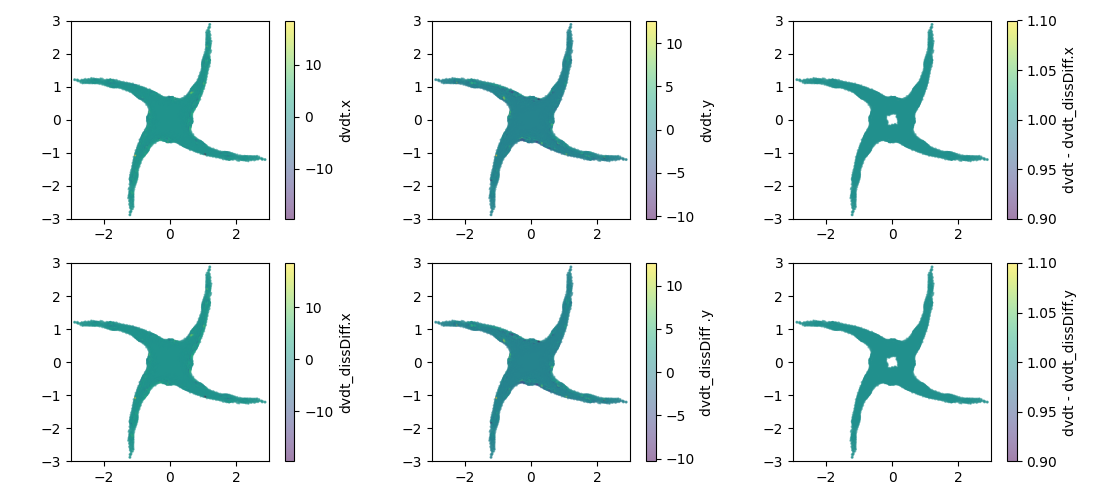

In [96]:
fig, axis = plt.subplots(2, 3, figsize=(11, 5), squeeze=False)

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = dvdt_dissDiff[:,0].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[0,0], label = 'dvdt.x')
sc = axis[0,1].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = dvdt_dissDiff[:,1].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[0,1], label = 'dvdt.y')

sc = axis[1,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = dvdt_dissDiff[:,0].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[1,0], label = 'dvdt_dissDiff.x')
sc = axis[1,1].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = dvdt_dissDiff[:,1].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[1,1], label = 'dvdt_dissDiff .y')

sc = axis[0,2].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = (dvdt_dissDiff / dvdt_dissDiff)[:,0].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[0,2], label = 'dvdt - dvdt_dissDiff.x')
sc = axis[1,2].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = (dvdt_dissDiff / dvdt_dissDiff)[:,1].cpu().numpy(), alpha = 0.5)
fig.colorbar(sc, ax = axis[1,2], label = 'dvdt - dvdt_dissDiff.y')

fig.tight_layout()


